# 11 — Predictor portfolio: the isolated predictor learns to choose itself

Notebook 10 isolated the predictor as a swappable module. This notebook
turns it into a **portfolio** with a **meta-controller** that learns online
which predictor to trust — the seed of the self-training system.

This is the LeCun architecture with the decoder removed, rebuilt on
contexts instead of raw tokens:

```text
  tokens ──encoder──▶ tid stream ──▶ HLLSet contexts (BSS soft keys)
      (LLM probes)      (ewm-sm)              │
                                              ▼
                              ┌──────────────────────────────┐
                              │  predictor portfolio         │
                              │  persistence / linear /      │
                              │  DFT-periodic / ridge        │
                              │         ▲                    │
                              │  meta-controller (EWMA       │
                              │  surprise → ε-greedy choice) │
                              └──────────┬───────────────────┘
                                         │ predicted next context
                                         ▼
                              curiosity: pick the query whose Pavlov
                              prototype is farthest from the prediction
                                         │
                              memory: materialized union state in restored
                              order is fed back into the LLM prompts
```

The ewm-sm apparatus is unchanged; only the notebook-level trainer layer
grew.

In [1]:
import os, json, subprocess, time

# Pin the RTX 3060 before torch is imported anywhere else in this kernel.
os.environ.setdefault("CUDA_DEVICE_ORDER", "PCI_BUS_ID")
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")

import numpy as np
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

EWM_SM = "/home/alexmy/SGS/SGS_lib/fractal_manifold_gen2/ewm-state-machine"
EWM_SCENE_BIN = os.path.join(EWM_SM, "target/debug/ewm-scene")
WORK = "/home/alexmy/.cache/ewm-multi-llm-predictor"
os.makedirs(WORK, exist_ok=True)

if not os.path.exists(EWM_SCENE_BIN):
    subprocess.run(["cargo", "build", "--quiet", "-p", "ewm-scene"], cwd=EWM_SM, check=True)

def ewm_scene(*args):
    r = subprocess.run([EWM_SCENE_BIN, *args], capture_output=True, text=True, timeout=600)
    if r.returncode != 0:
        raise RuntimeError(f"ewm-scene failed: {r.stderr[-800:]}")
    return json.loads(r.stdout.strip())

print("torch", torch.__version__, "| cuda", torch.cuda.is_available(),
      torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu")
print("ewm-scene:", EWM_SCENE_BIN)
print("work:", WORK)

torch 2.6.0+cu124 | cuda True NVIDIA GeForce RTX 3060
ewm-scene: /home/alexmy/SGS/SGS_lib/fractal_manifold_gen2/ewm-state-machine/target/debug/ewm-scene
work: /home/alexmy/.cache/ewm-multi-llm-predictor


In [2]:
# ── Three real small LLM probes (same as notebooks 09/10) ─────────────────
MODELS = {
    "llm_a": "deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B",
    "llm_b": "Qwen/Qwen2.5-1.5B-Instruct",
    "llm_c": "gpt2",
}

PROMPTS = [
    "What is the capital of France?",
    "Explain gravity in one sentence.",
    "Write a haiku about rain.",
    "What is the meaning of life?",
    "Name three planets in our solar system.",
    "What is the speed of light?",
    "Define entropy in simple words.",
    "Who wrote Romeo and Juliet?",
]
MAX_NEW = 48

loaded = {}
for name, model_id in MODELS.items():
    t0 = time.time()
    tok = AutoTokenizer.from_pretrained(model_id, local_files_only=True)
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token
    model = AutoModelForCausalLM.from_pretrained(
        model_id, local_files_only=True, dtype=torch.float16, device_map="auto")
    model.eval()
    loaded[name] = (tok, model)
    print(f"loaded {name:6s} {model_id:48s} in {time.time() - t0:4.1f}s on {model.device}")

names = list(MODELS)

loaded llm_a  deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B        in  3.4s on cuda:0
loaded llm_b  Qwen/Qwen2.5-1.5B-Instruct                       in  2.4s on cuda:0
loaded llm_c  gpt2                                             in  0.6s on cuda:0


## §1 — Open loop: the Pavlov cycle, recorded by the apparatus

The 8-query bank is played 3 times with no feedback (T=24). This is the
training set for the predictors: a deterministic, period-8 trajectory in
BSS space.

In [3]:
T_OL = 3 * len(PROMPTS)   # 24 frames

steps_ol = {n: [] for n in names}
t_gen = time.time()
for t in range(T_OL):
    prompt = PROMPTS[t % len(PROMPTS)]
    for n in names:
        tok, model = loaded[n]
        inputs = tok(prompt, return_tensors="pt").to(model.device)
        with torch.no_grad():
            out = model.generate(**inputs, max_new_tokens=MAX_NEW, do_sample=False,
                                 pad_token_id=tok.eos_token_id)
        new_ids = out[0, inputs["input_ids"].shape[1]:].cpu().tolist()
        steps_ol[n].append([f"tid{i}" for i in new_ids])
print(f"generated open loop: {T_OL} frames in {time.time() - t_gen:5.1f}s")

PYRAMID_OL = f"{WORK}/open_pyramid.jsonl"
with open(PYRAMID_OL, "w") as fh:
    for t in range(T_OL):
        fh.write(json.dumps({"id": t + 1, "perceptrons": {n: steps_ol[n][t] for n in names}}) + "\n")

union_ol = [[tok for n in names for tok in steps_ol[n][t]] for t in range(T_OL)]
UNION_OL = f"{WORK}/open_union.jsonl"
with open(UNION_OL, "w") as fh:
    for t, toks in enumerate(union_ol, 1):
        fh.write(json.dumps({"id": t, "tokens": toks}) + "\n")
print("wrote", PYRAMID_OL, "and", UNION_OL)

generated open loop: 24 frames in  92.3s
wrote /home/alexmy/.cache/ewm-multi-llm-predictor/open_pyramid.jsonl and /home/alexmy/.cache/ewm-multi-llm-predictor/open_union.jsonl


In [4]:
# ── The apparatus records the reflex; the trainer reads fixed-dim contexts ─
pyr_ol = ewm_scene("pyramid", PYRAMID_OL)
uni_ol = ewm_scene("ingest", UNION_OL)
same_union = all(uni_ol["frames"][i]["key"] == pyr_ol["frames"][i]["union_key"] for i in range(T_OL))
print("union discovered twice, keys agree (24/24):", same_union)

cum = {n: sorted({tok for t in range(T_OL) for tok in steps_ol[n][t]}) for n in names}
FRAME_LLMS = f"{WORK}/frame_llms.json"
with open(FRAME_LLMS, "w") as fh:
    json.dump({"dimensions": [{"name": n, "tokens": cum[n]} for n in names]}, fh)

proj_ol = ewm_scene("project", UNION_OL, "--frame", FRAME_LLMS)
M_ol = np.array([f["bss"] for f in proj_ol["frames"]])
M_proto = M_ol[:len(PROMPTS)]
print("frame dims:", proj_ol["names"], "pops:", proj_ol["pops"])
print("M_ol shape:", M_ol.shape, "| period-8 replay:", np.allclose(M_ol[8], M_ol[0]))

def dft_period(X, tol=0.5):
    """Dominant period of a (t, d) series via its average power spectrum."""
    t = X.shape[0]
    Xc = X - X.mean(axis=0)
    p = np.abs(np.fft.rfft(Xc, axis=0)) ** 2
    p[0] = 0.0
    total = p.sum(axis=1)
    k_hi = t // 2
    if k_hi < 2:
        return None
    k_best = int(np.argmax(total[2:k_hi + 1]) + 2)
    peak = total[k_best]
    if peak <= 0:
        return None
    cands = [k for k in range(2, k_hi + 1) if total[k] >= tol * peak]
    return t / min(cands)

print("DFT-detected period of the Pavlov cycle:", dft_period(M_ol), "steps")

union discovered twice, keys agree (24/24): True
frame dims: ['llm_a', 'llm_b', 'llm_c'] pops: [411, 630, 211]
M_ol shape: (24, 3) | period-8 replay: True
DFT-detected period of the Pavlov cycle: 8.0 steps


## §2 — The predictor portfolio

One interface, four interchangeable predictors. Each takes the trajectory
history (BSS rows) and returns the predicted next row:

| Predictor | Model | Character |
| - | - | - |
| `persistence` | `x̂(t+1) = x(t)` | zero-cost baseline |
| `linear` | `x̂(t+1) = 2x(t) − x(t−1)` | local extrapolation |
| `dft-periodic` | dominant period via DFT, phase-average continuation | spectral, no learning |
| `ridge` | linear model over `[x(t), Δx(t), sin, cos]` with an L2-regularized fit on all history | **learns online** |

The meta-controller tracks an EWMA of each predictor's surprise and chooses
ε-greedily — so the predictor layer trains itself to pick the most
appropriate predictor.

In [5]:
def persistence(hist):
    return hist[-1].copy()

def linear(hist):
    if len(hist) < 2:
        return hist[-1].copy()
    return 2.0 * hist[-1] - hist[-2]

def dft_predictor(hist):
    t = hist.shape[0]
    if t < 8:
        return persistence(hist)
    P = dft_period(hist)
    if P is None:
        return persistence(hist)
    P = max(2, min(int(round(P)), t - 1))
    idx = [n for n in range(t) if n % P == t % P]
    if idx:
        return hist[idx].mean(axis=0)
    return persistence(hist)

def ridge_predictor(hist, lam=1e-3):
    t = hist.shape[0]
    if t < 4:
        return persistence(hist)
    P = dft_period(hist)
    if P is None:
        P = float(t)
    P = max(2.0, P)
    d = hist.shape[1]
    def feats(i):
        dm = hist[i] - hist[i - 1] if i > 0 else np.zeros(d)
        ph = 2.0 * np.pi * i / P
        return np.concatenate([hist[i], dm, [np.sin(ph), np.cos(ph)]])
    X = np.array([feats(i) for i in range(t - 1)])
    Y = hist[1:]
    XtX = X.T @ X + lam * np.eye(X.shape[1])
    W = np.linalg.solve(XtX, X.T @ Y)
    return feats(t - 1) @ W

predictors = {
    "persistence": persistence,
    "linear": linear,
    "dft-periodic": dft_predictor,
    "ridge": ridge_predictor,
}

# Offline benchmark: one-step error over the Pavlov cycle (online protocol).
print("offline one-step benchmark on the Pavlov cycle:")
for name, fn in predictors.items():
    errs = [float(np.linalg.norm(fn(M_ol[:t + 1]) - M_ol[t + 1]))
            for t in range(2, T_OL - 1)]
    print(f"  {name:12s} mean |err| = {np.mean(errs):.6f}")

offline one-step benchmark on the Pavlov cycle:
  persistence  mean |err| = 0.119249
  linear       mean |err| = 0.209533
  dft-periodic mean |err| = 0.081060
  ridge        mean |err| = 0.108854


## §3 — Closed loop: the meta-controller learns to choose

The loop is notebook 10's loop, but the prediction feeding the curiosity
policy comes from the **selected** predictor:

1. every predictor forecasts the next BSS context from the combined history
   (open loop + closed loop so far);
2. the meta-controller picks one by EWMA surprise (ε-greedy, warm-up random
   for the first two steps);
3. curiosity chooses the query whose Pavlov prototype is farthest from the
   selected prediction;
4. memory (materialized union state, restored order) is fed back into the
   three LLMs;
5. after the LLMs respond, every predictor's surprise is updated — this is
   the self-training signal.

In [6]:
def memory_tokens(ordered, cap=24):
    toks = []
    for t in ordered:
        if not toks or toks[-1] != t:
            toks.append(t)
    return toks[-cap:]

def build_prompt(mem_toks, query):
    if mem_toks:
        return "memory: " + " ".join(mem_toks) + "\nQuery: " + query
    return "Query: " + query

T_CL = 16
UNION_CL = f"{WORK}/closed_union.jsonl"
open(UNION_CL, "w").close()

hist = M_ol.copy()                       # combined history, same coordinates
M_cl_rows = []
query_log = []
choice_log = []
surprise_meta = []
surprise_all = {name: [] for name in predictors}
ewma = {name: 1.0 for name in predictors}
ewma_log = {name: [] for name in predictors}
rng = np.random.default_rng(0)

mat_ol = ewm_scene("materialize", UNION_OL)
mem = memory_tokens(mat_ol["frames"][-1]["ordered"])

t_gen = time.time()
for t in range(T_CL):
    if t == 0:
        chosen = None
        preds = None
        q = 0
    else:
        preds = {name: fn(hist) for name, fn in predictors.items()}
        # Meta-selection: warm-up random, then epsilon-greedy over EWMA.
        if t <= 2:
            chosen = rng.choice(list(predictors))
        elif rng.random() < 0.1:
            chosen = rng.choice(list(predictors))
        else:
            chosen = min(predictors, key=lambda n: ewma[n])
        pred_sel = preds[chosen]
        candidates = [j for j in range(len(PROMPTS)) if j != query_log[-1]]
        q = max(candidates, key=lambda j: float(np.linalg.norm(pred_sel - M_proto[j])))
    choice_log.append(chosen)
    query_log.append(q)

    prompt = build_prompt(mem, PROMPTS[q])
    frame_toks = {}
    for n in names:
        tok, model = loaded[n]
        inputs = tok(prompt, return_tensors="pt").to(model.device)
        with torch.no_grad():
            out = model.generate(**inputs, max_new_tokens=MAX_NEW, do_sample=False,
                                 pad_token_id=tok.eos_token_id)
        new_ids = out[0, inputs["input_ids"].shape[1]:].cpu().tolist()
        frame_toks[n] = [f"tid{i}" for i in new_ids]

    toks = [x for n in names for x in frame_toks[n]]
    with open(UNION_CL, "a") as fh:
        fh.write(json.dumps({"id": t + 1, "tokens": toks}) + "\n")

    proj_cl = ewm_scene("project", UNION_CL, "--frame", FRAME_LLMS)
    m_t = np.array(proj_cl["frames"][-1]["bss"])
    M_cl_rows.append(m_t)

    if t > 0:
        for name in predictors:
            s = float(np.linalg.norm(preds[name] - m_t))
            surprise_all[name].append(s)
            ewma[name] = 0.8 * ewma[name] + 0.2 * s
        surprise_meta.append(float(np.linalg.norm(preds[chosen] - m_t)))
    else:
        for name in predictors:
            surprise_all[name].append(0.0)
        surprise_meta.append(0.0)

    for name in predictors:
        ewma_log[name].append(ewma[name])

    hist = np.vstack([hist, m_t])

    mat_cl = ewm_scene("materialize", UNION_CL)
    mem = memory_tokens(mat_cl["frames"][-1]["ordered"])

    if t % 4 == 0 or t == T_CL - 1:
        print(f"t={t:2d} q={q}  chosen={str(chosen):12s}  surprise={surprise_meta[-1]:.4f}")

M_cl = np.array(M_cl_rows)
print(f"closed loop: {T_CL} frames in {time.time() - t_gen:5.1f}s")

t= 0 q=0  chosen=None          surprise=0.0000
t= 4 q=7  chosen=persistence   surprise=0.0831
t= 8 q=7  chosen=persistence   surprise=0.0831
t=12 q=7  chosen=persistence   surprise=0.0831
t=15 q=3  chosen=ridge         surprise=0.0432
closed loop: 16 frames in  66.3s


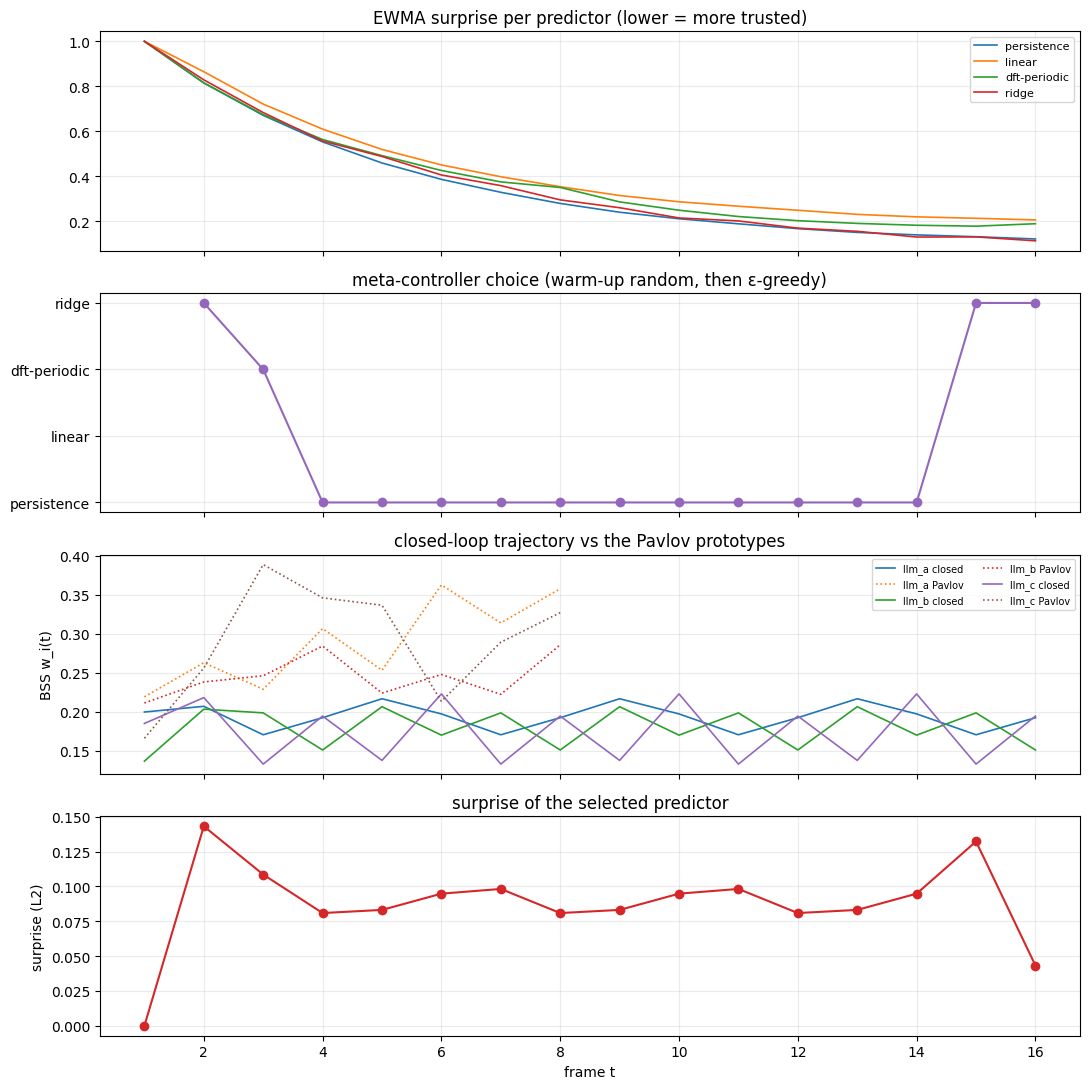

In [7]:
%matplotlib inline
import matplotlib.pyplot as plt

names_p = list(predictors)
choice_idx = [names_p.index(c) if c is not None else np.nan for c in choice_log]
t_axis_cl = np.arange(1, T_CL + 1)

fig, axes = plt.subplots(4, 1, figsize=(11, 11), sharex=True)
for name in predictors:
    axes[0].plot(t_axis_cl, ewma_log[name], label=name, lw=1.2)
axes[0].set_title("EWMA surprise per predictor (lower = more trusted)")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.25)

axes[1].plot(t_axis_cl, choice_idx, "o-", color="tab:purple")
axes[1].set_yticks(range(len(names_p)), names_p)
axes[1].set_title("meta-controller choice (warm-up random, then ε-greedy)")
axes[1].grid(alpha=0.25)

for i, n in enumerate(names):
    axes[2].plot(t_axis_cl, M_cl[:, i], lw=1.2, label=f"{n} closed")
    axes[2].plot(np.arange(1, len(PROMPTS) + 1), M_proto[:, i], ls=":", lw=1.2,
                 label=f"{n} Pavlov")
axes[2].set_ylabel("BSS w_i(t)")
axes[2].set_title("closed-loop trajectory vs the Pavlov prototypes")
axes[2].legend(fontsize=7, ncol=2)
axes[2].grid(alpha=0.25)

axes[3].plot(t_axis_cl, surprise_meta, "o-", color="tab:red")
axes[3].set_ylabel("surprise (L2)")
axes[3].set_xlabel("frame t")
axes[3].set_title("surprise of the selected predictor")
axes[3].grid(alpha=0.25)

plt.tight_layout()
plt.savefig(f"{WORK}/predictor_meta.png", dpi=110)
plt.show()

In [8]:
# ── Who did the meta-controller learn to trust? ────────────────────────────
counts = {name: choice_log.count(name) for name in predictors}
print("meta-controller choices:", counts)
print()
print("mean one-step surprise over the closed loop:")
for name in predictors:
    print(f"  {name:12s} {np.mean(surprise_all[name][1:]):.6f}   (final EWMA {ewma[name]:.4f})")
print(f"  {'meta':12s} {np.mean(surprise_meta[1:]):.6f}")
best = min(predictors, key=lambda n: np.mean(surprise_all[n][1:]))
print()
print("best single predictor:", best)
print("meta mean surprise / best single =",
      round(np.mean(surprise_meta[1:]) / max(np.mean(surprise_all[best][1:]), 1e-12), 3))
print()
print("separation of concerns: ewm-sm commands unchanged — pyramid, ingest,")
print("sidecar/project, materialize — while the predictor layer was fully swapped.")

meta-controller choices: {'persistence': 11, 'linear': 0, 'dft-periodic': 1, 'ridge': 3}

mean one-step surprise over the closed loop:
  persistence  0.087981   (final EWMA 0.1208)
  linear       0.181334   (final EWMA 0.2055)
  dft-periodic 0.142893   (final EWMA 0.1886)
  ridge        0.095713   (final EWMA 0.1126)
  meta         0.093342

best single predictor: persistence
meta mean surprise / best single = 1.061

separation of concerns: ewm-sm commands unchanged — pyramid, ingest,
sidecar/project, materialize — while the predictor layer was fully swapped.


## Summary

- The predictor is now a **portfolio behind one interface**: persistence,
  linear, DFT-periodic, and an online ridge model. Each is a pure function
  of the HLLSet-context history (BSS rows) — no tokens, no decoder.
- The **meta-controller** tracks EWMA surprise per predictor and chooses
  ε-greedily online: the predictor layer starts to train itself to pick the
  most appropriate predictor for the current phase of the system.
- The loop remains closed through memory (materialized union state in
  restored order) and curiosity (selected prediction → farthest Pavlov
  prototype).
- ewm-sm is untouched. The LeCun separation — encoder, context, predictor,
  no decoder — holds, with HLLSets as the contexts.

Next: replace the EWMA meta-controller with a small policy that also
conditions on the trajectory features (a learned selector), and let the
surprise signal update both the selectors and the predictors.